In [1]:
import tarfile
import pandas as pd
import numpy as np
import re
from datetime import datetime

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Conv1D, MaxPooling1D

from matplotlib import pyplot as plt

### Read data

In [3]:
filename = "training_data.tar.gz"

data = tarfile.open(filename, "r:gz")
data.extractall()
data.close()

In [4]:
b = open('ghl_gold.fa','r')
bind = b.readlines()
b.close()

u = open('ghl_gold_random.fa','r')
unbind = u.readlines()
u.close()

### Data preprocessing

In [5]:
bind = [v for v in bind if '>' not in v]
bind = [s.replace('\n', '') for s in bind]
bind = [x.upper() for x in bind]

unbind = [v for v in unbind if '>' not in v]
unbind = [s.replace('\n', '') for s in unbind]
unbind = [x.upper() for x in unbind]

In [6]:
print(len(bind), len(unbind))

1400090 1400090


In [7]:
bind_label = [1 for i in range(len(bind))]
unbind_label = [0 for i in range(len(unbind))]

In [8]:
bind_dict = {"seq":bind, "label":bind_label}
unbind_dict = {"seq":unbind, "label":unbind_label}

In [9]:
bind_df = pd.DataFrame(bind_dict)
unbind_df = pd.DataFrame(unbind_dict)

In [10]:
df = pd.concat([bind_df, unbind_df])

##### split the dataset

In [11]:
from sklearn.utils import shuffle

new_df = shuffle(df)
new_df = new_df.reset_index()

In [12]:
x = new_df.seq
y = new_df.label

In [13]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=40)

##### One-hot Encoding

In [14]:
LE = LabelEncoder()
LE.fit(['A', 'C', 'G', 'T', 'N'])

LabelEncoder()

In [15]:
start = datetime.now()

for index, row in x_train.items():
  x_train[index] = LE.transform(list(row))

for index, row in x_test.items():
  x_test[index] = LE.transform(list(row))

x_train = to_categorical(x_train.values.tolist())
x_test = to_categorical(x_test.values.tolist())

y_train = to_categorical(y_train.values.tolist())
y_t = to_categorical(y_test.values.tolist())

end = datetime.now()
print("encoding running time : "+str(end-start))

encoding running time : 0:03:18.737917


### CNN model

In [16]:
model=Sequential()
model.add(Conv1D(filters=64, kernel_size=3, strides=1, padding='valid', input_shape=(20,5), activation='relu'))
model.add(MaxPooling1D(pool_size=3, strides=1, padding='valid'))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(2, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [17]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv1d (Conv1D)              (None, 18, 64)            1024      
_________________________________________________________________
max_pooling1d (MaxPooling1D) (None, 16, 64)            0         
_________________________________________________________________
flatten (Flatten)            (None, 1024)              0         
_________________________________________________________________
dense (Dense)                (None, 128)               131200    
_________________________________________________________________
dropout (Dropout)            (None, 128)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 2)                 258       
Total params: 132,482
Trainable params: 132,482
Non-trainable params: 0
__________________________________________________

In [18]:
history = model.fit(x_train, y_train, epochs=10, validation_split = 0.2)

Epoch 1/10
56004/56004 [==============================] - 215s 4ms/step - loss: 0.3247 - accuracy: 0.8600 - val_loss: 0.2994 - val_accuracy: 0.8749
Epoch 2/10
56004/56004 [==============================] - 212s 4ms/step - loss: 0.2998 - accuracy: 0.8733 - val_loss: 0.2973 - val_accuracy: 0.8744
Epoch 3/10
56004/56004 [==============================] - 210s 4ms/step - loss: 0.2954 - accuracy: 0.8753 - val_loss: 0.2920 - val_accuracy: 0.8773
Epoch 4/10
56004/56004 [==============================] - 210s 4ms/step - loss: 0.2928 - accuracy: 0.8766 - val_loss: 0.2907 - val_accuracy: 0.8771
Epoch 5/10
56004/56004 [==============================] - 213s 4ms/step - loss: 0.2911 - accuracy: 0.8774 - val_loss: 0.2894 - val_accuracy: 0.8776
Epoch 6/10
56004/56004 [==============================] - 228s 4ms/step - loss: 0.2892 - accuracy: 0.8779 - val_loss: 0.2894 - val_accuracy: 0.8780
Epoch 7/10
56004/56004 [==============================] - 224s 4ms/step - loss: 0.2889 - accuracy: 0.8786 - val_

##### Evaluation

Accuracy

In [19]:
score = model.evaluate(x_test, y_t, verbose=1)
print("score = " + str(round(score[1],2)))

17502/17502 [==============================] - 27s 2ms/step - loss: 0.2885 - accuracy: 0.8784
score = 0.88


loss-epoch curve

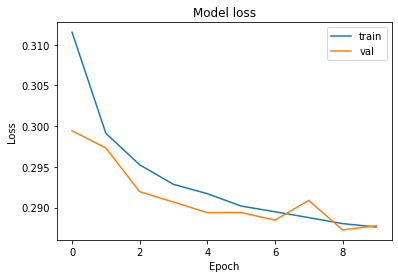

In [20]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

precision-recall curve

In [21]:
probs = model.predict(x_test, verbose=0)[:,1]

In [22]:
precision, recall, thresholds = precision_recall_curve(y_test.values, probs)

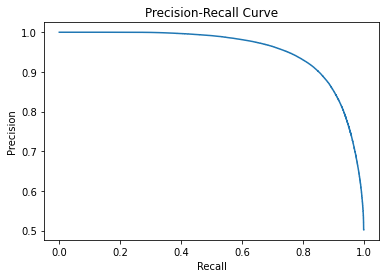

In [23]:
plt.plot(recall, precision)

plt.title('Precision-Recall Curve')

plt.xlabel('Recall')
plt.ylabel('Precision')

# plt.legend()
plt.show()

ROC curve & AUC

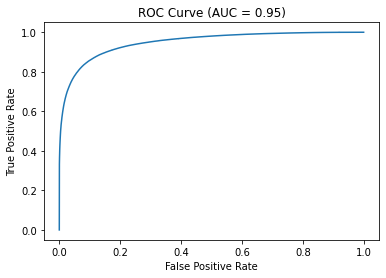

In [24]:
auc = roc_auc_score(y_test.values, probs)
fpr, tpr, _ = roc_curve(y_test.values, probs)

plt.plot(fpr, tpr)
plt.title('ROC Curve (AUC = ' + str(round(auc,2)) + ')')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()